<a href="https://colab.research.google.com/github/samruddhi2904/Samruddhi-Landge/blob/main/Ghiblitrend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('Ghiblitrend.csv')

In [8]:
#Basic Info
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   image_id               500 non-null    object 
 1   user_id                500 non-null    object 
 2   prompt                 500 non-null    object 
 3   likes                  500 non-null    int64  
 4   shares                 500 non-null    int64  
 5   comments               500 non-null    int64  
 6   platform               500 non-null    object 
 7   generation_time        500 non-null    float64
 8   gpu_usage              500 non-null    int64  
 9   file_size_kb           500 non-null    int64  
 10  resolution             500 non-null    object 
 11  style_accuracy_score   500 non-null    int64  
 12  is_hand_edited         500 non-null    object 
 13  ethical_concerns_flag  500 non-null    object 
 14  creation_date          500 non-null    object 
 15  top_co

In [9]:
# Create Data Subsets
subset_instagram = df[df['platform'] == 'Instagram']
subset_high_accuracy = df[df['style_accuracy_score'] > 85]

In [10]:
#Merge Data - Simulate user dataset
user_info = pd.DataFrame({
    'user_id': df['user_id'].unique()[:5],
    'user_name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'country': ['USA', 'UK', 'Canada', 'Australia', 'India']
})
merged_df = pd.merge(df, user_info, on='user_id', how='left')


In [11]:
#Sort Data
sorted_df = df.sort_values(by=['likes', 'generation_time'], ascending=[False, True])

In [12]:
#Transpose Data
transposed = df.head(3).transpose()
print(transposed)

                                                                       0  \
image_id                            77ce5c72-eb45-4651-bcb1-c0677c0fceaf   
user_id                                                         6a7adf3d   
prompt                      Studio Ghibli-inspired ocean with giant fish   
likes                                                                916   
shares                                                               410   
comments                                                             555   
platform                                                          Reddit   
generation_time                                                      4.8   
gpu_usage                                                             49   
file_size_kb                                                        1684   
resolution                                                     1024x1024   
style_accuracy_score                                                  89   
is_hand_edit

In [13]:
#Shape and Reshape
print("Original Shape:", df.shape)
reshaped = df[['likes', 'shares', 'comments']].values.reshape(-1, 3)
print("Reshaped to (n, 3):", reshaped.shape)

Original Shape: (500, 16)
Reshaped to (n, 3): (500, 3)


In [14]:
# Data Cleaning
df_cleaned = df.drop_duplicates()
df_cleaned['is_hand_edited'] = df_cleaned['is_hand_edited'].replace({'Yes': True, 'No': False})

<ipython-input-14-f5fa2324fa1e>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['is_hand_edited'] = df_cleaned['is_hand_edited'].replace({'Yes': True, 'No': False})


In [16]:
#Data Integration
# Simulating platform popularity
platform_popularity = pd.DataFrame({
    'platform': ['Reddit', 'Instagram', 'TikTok', 'Twitter'],
    'avg_engagement': [450, 600, 520, 470]
    })
integrated_df = pd.merge(df, platform_popularity, on='platform', how='left')

In [17]:
# Data Transformation
df['engagement_score'] = df['likes'] + df['shares'] + df['comments']
df['creation_date'] = pd.to_datetime(df['creation_date'])

In [18]:
# Error Correcting - Fix outliers
df.loc[df['generation_time'] > 60, 'generation_time'] = np.nan  # assuming 60s is max reasonable
df['generation_time'].fillna(df['generation_time'].mean(), inplace=True)

<ipython-input-18-83a54af09a10>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['generation_time'].fillna(df['generation_time'].mean(), inplace=True)


In [19]:
#Data Model Building - Simple Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['generation_time', 'gpu_usage', 'file_size_kb']]
y = df['likes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print("Model Score (R^2):", model.score(X_test, y_test))

Model Score (R^2): -0.006333364654065754


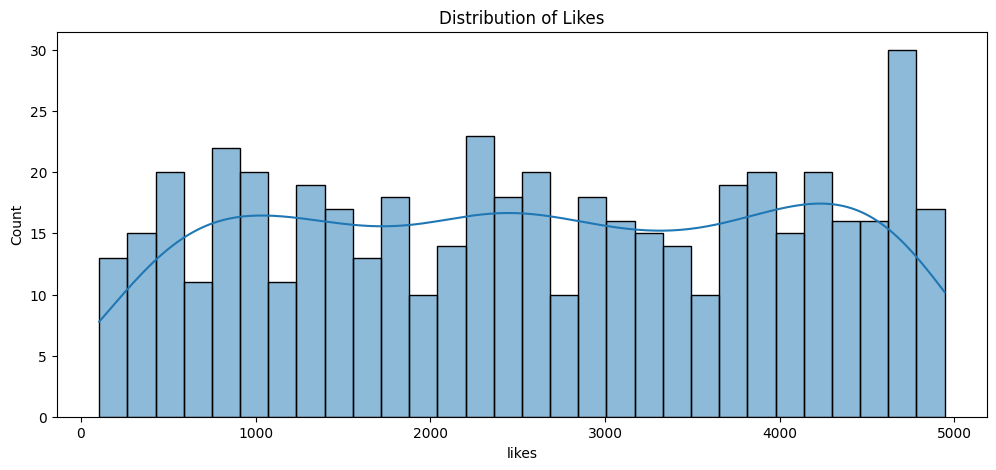

In [21]:
# Data Visualization
plt.figure(figsize=(12, 5))
sns.histplot(df['likes'], bins=30, kde=True)
plt.title("Distribution of Likes")
plt.show()



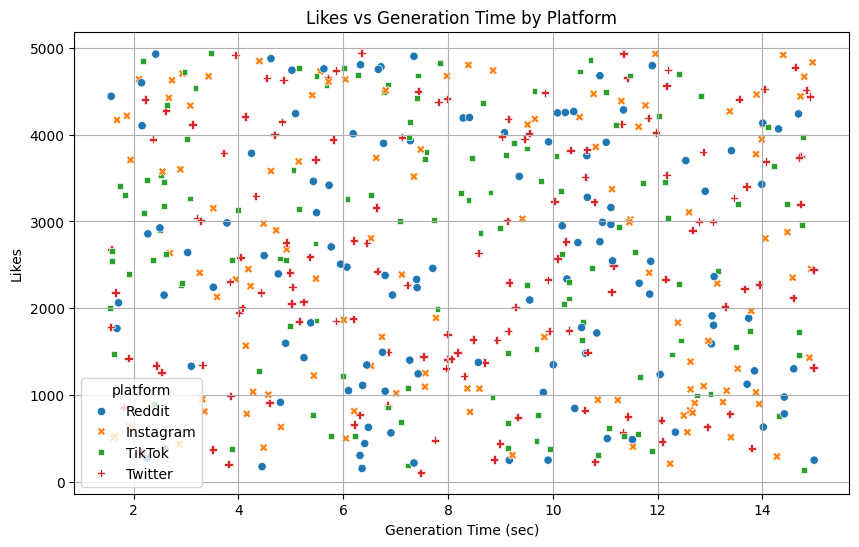

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='generation_time', y='likes', hue='platform', style='platform')
plt.title("Likes vs Generation Time by Platform")
plt.xlabel("Generation Time (sec)")
plt.ylabel("Likes")
plt.grid(True)
plt.show()

<ipython-input-23-0370c83162fa>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='platform', y='style_accuracy_score', palette="Set2")


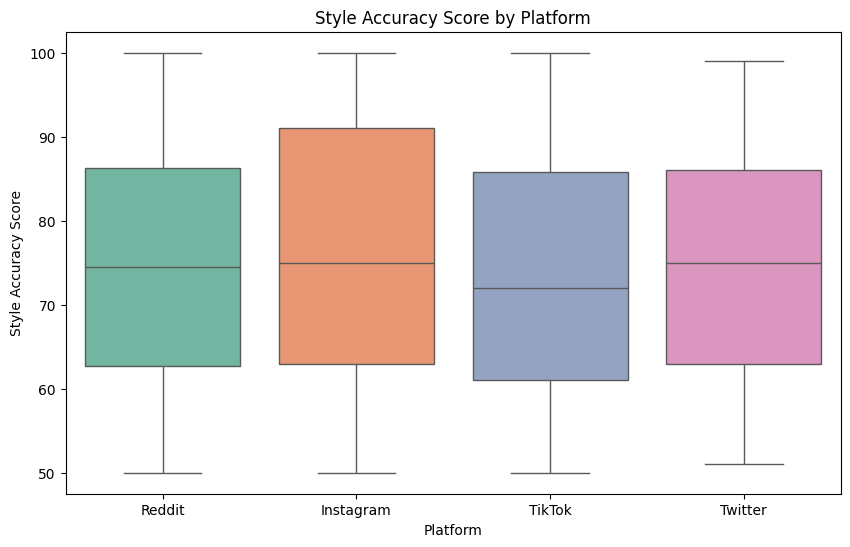

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='platform', y='style_accuracy_score', palette="Set2")
plt.title("Style Accuracy Score by Platform")
plt.ylabel("Style Accuracy Score")
plt.xlabel("Platform")
plt.show()

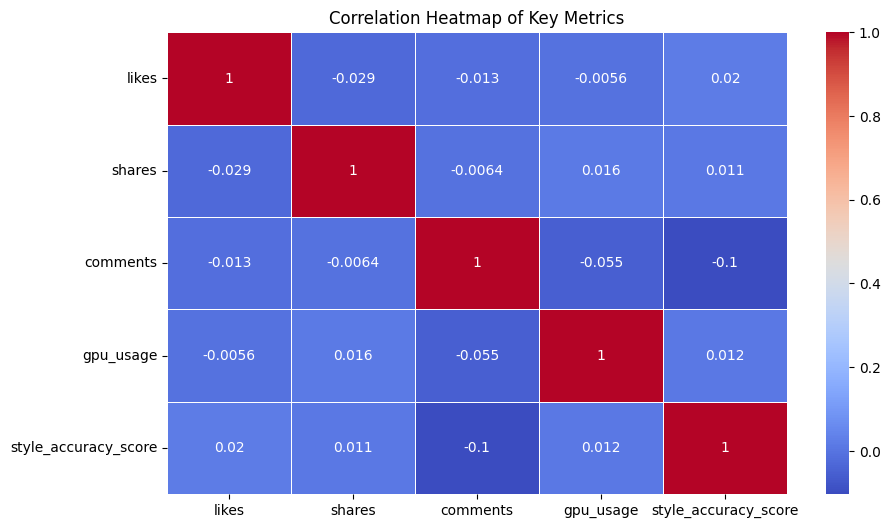

In [24]:
plt.figure(figsize=(10, 6))
correlation_matrix = df[['likes', 'shares', 'comments', 'gpu_usage', 'style_accuracy_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Key Metrics")
plt.show()

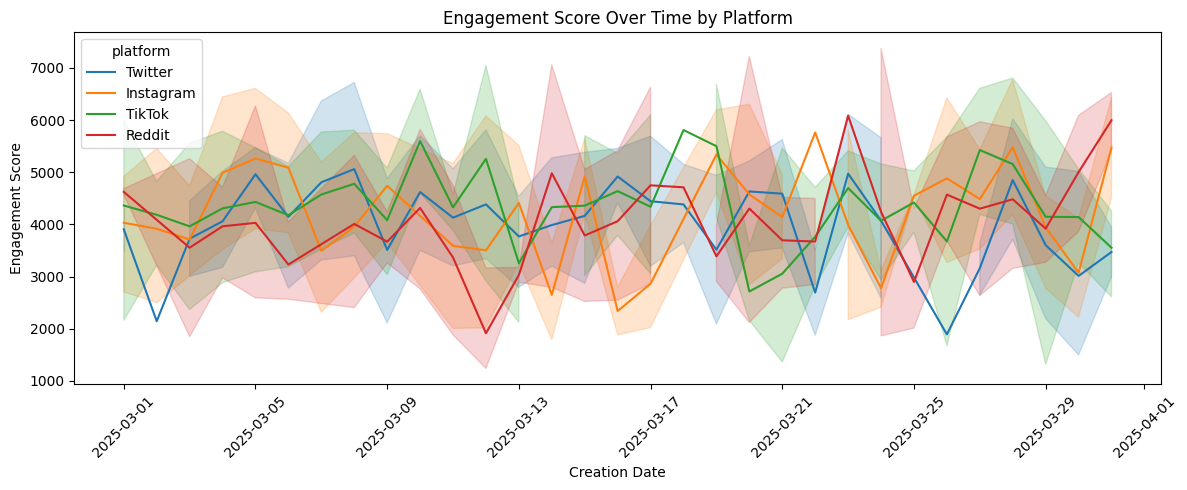

In [25]:
# Create engagement score and parse dates
df['engagement_score'] = df['likes'] + df['shares'] + df['comments']
df['creation_date'] = pd.to_datetime(df['creation_date'])

# Line plot over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df.sort_values('creation_date'), x='creation_date', y='engagement_score', hue='platform')
plt.title("Engagement Score Over Time by Platform")
plt.xlabel("Creation Date")
plt.ylabel("Engagement Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

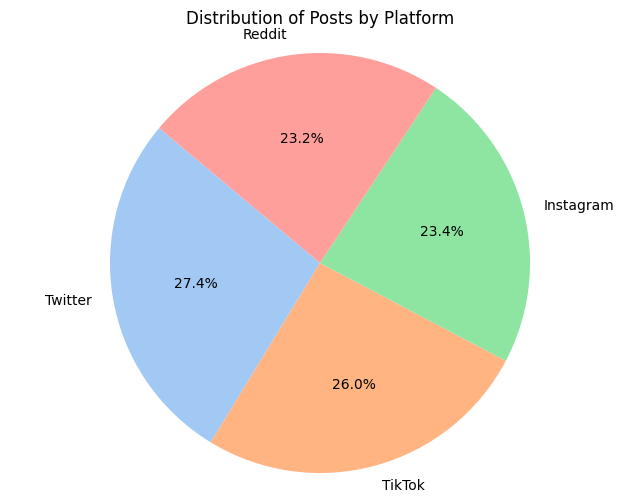

In [26]:
# Count number of posts per platform
platform_counts = df['platform'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 6))
colors = sns.color_palette('pastel')[0:len(platform_counts)]
plt.pie(platform_counts, labels=platform_counts.index, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Posts by Platform')
plt.axis('equal')  # Equal aspect ratio makes the pie circular
plt.show()

In [28]:
# Create binary target: High (1) if likes > median, else Low (0)
df['high_engagement'] = (df['likes'] > df['likes'].median()).astype(int)

In [29]:
#Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Features & Target
features = ['generation_time', 'gpu_usage', 'file_size_kb', 'style_accuracy_score']
X = df[features]
y = df['high_engagement']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



[[21 31]
 [22 26]]
              precision    recall  f1-score   support

           0       0.49      0.40      0.44        52
           1       0.46      0.54      0.50        48

    accuracy                           0.47       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.47      0.47      0.47       100



In [31]:
#KNN
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# Create binary target: High engagement = 1 if likes > median
df['high_engagement'] = (df['likes'] > df['likes'].median()).astype(int)

# Feature set and target
features = ['generation_time', 'gpu_usage', 'file_size_kb', 'style_accuracy_score']
X = df[features]
y = df['high_engagement']

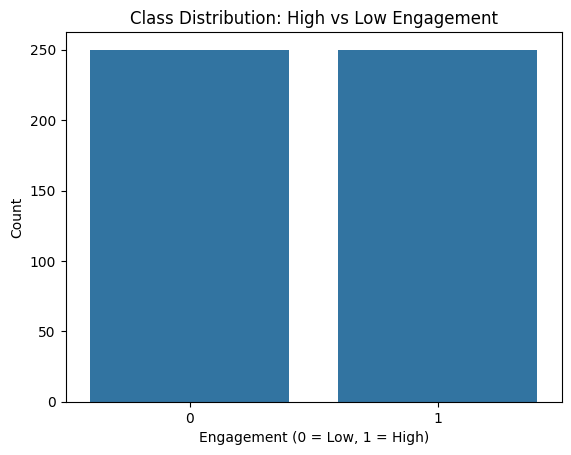

In [33]:
# Visualize class balance
sns.countplot(x=y)
plt.title("Class Distribution: High vs Low Engagement")
plt.xlabel("Engagement (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()

In [34]:
#  Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Apply KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [36]:
y_pred = knn.predict(X_test)

In [37]:
# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[27 25]
 [20 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.52      0.55        52
           1       0.53      0.58      0.55        48

    accuracy                           0.55       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.55      0.55      0.55       100

Accuracy Score: 0.55


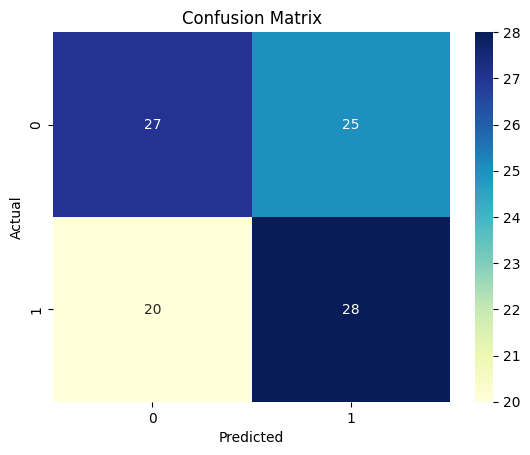

In [38]:
# Visualize Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()